In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# Load the dataset directly from a reliable public source
url = "https://www.dropbox.com/scl/fi/q9l9zkdkwep6wyac0j8yh/Mall_Customers.csv?rlkey=skgp8l5c1b29d8t6u8i667bte&st=cq5ci195&dl=1"
df = pd.read_csv(url)

print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nMissing values per column:\n", df.isnull().sum())
print("\nFirst 5 rows:\n", df.head())

Dataset Dimensions: 200 rows, 5 columns

Missing values per column:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

First 5 rows:
    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


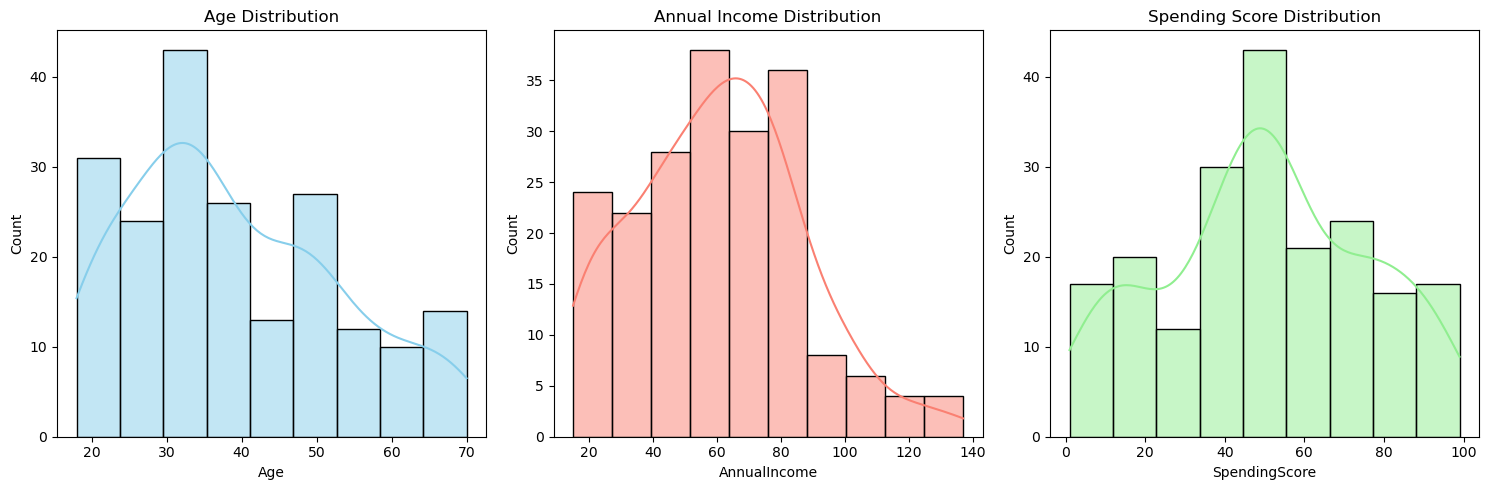

In [2]:
# Create distribution plots using subplots

df.columns = ['CustomerID', 'Gender', 'Age', 'AnnualIncome', 'SpendingScore']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.histplot(df['Age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Age Distribution')

sns.histplot(df['AnnualIncome'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Annual Income Distribution')

sns.histplot(df['SpendingScore'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Spending Score Distribution')

plt.tight_layout()
plt.savefig('eda_distributions.png')

In [3]:
# Select continuous numerical columns
features = ['Age', 'AnnualIncome', 'SpendingScore']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

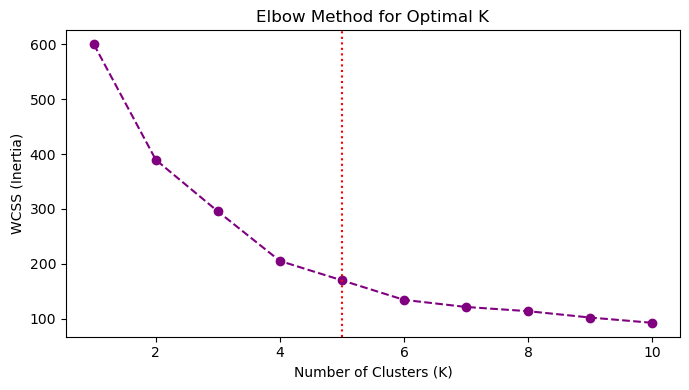

In [4]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Draw the Elbow Curve
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, 11), wcss, marker='o', linestyle='--', color='purple')
ax.set_title('Elbow Method for Optimal K')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('WCSS (Inertia)')

# Draw a line where the drop flattens out (the 'elbow')
ax.axvline(x=5, color='red', linestyle=':')
plt.tight_layout()

In [5]:
# Initialize and fit the final model
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

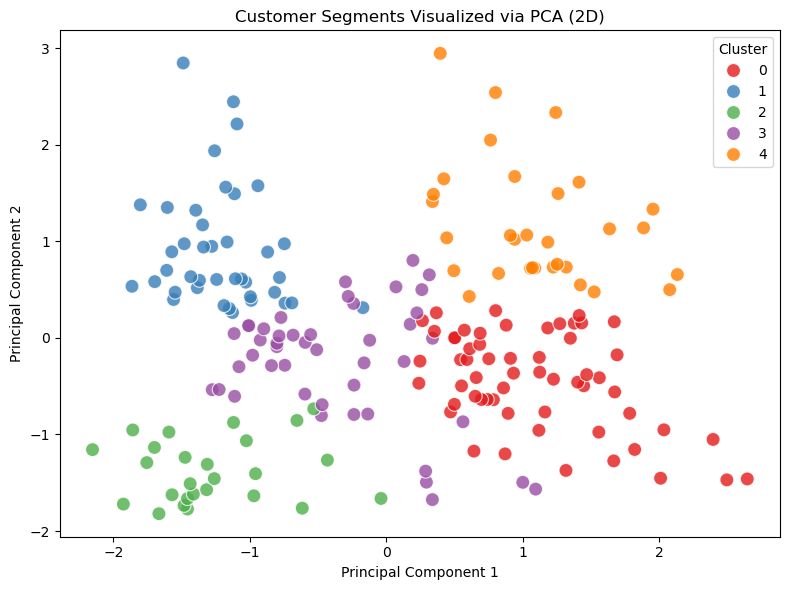

In [6]:
# Reduce from 3D to 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Store components in our dataframe
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

# Plot the identified customer segments
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='Set1', s=100, alpha=0.8, ax=ax)
ax.set_title('Customer Segments Visualized via PCA (2D)')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.legend(title='Cluster')
plt.tight_layout()

In [7]:
profiles = df.groupby('Cluster')[['Age', 'AnnualIncome', 'SpendingScore']].mean()
profiles['Volume_Count'] = df['Cluster'].value_counts()

print(profiles)
print("\n====================== CORPORATE SYNTHESIS ======================")

for cluster_id in sorted(df['Cluster'].unique()):
    sub_block = df[df['Cluster'] == cluster_id]
    avg_age = sub_block['Age'].mean()
    avg_inc = sub_block['AnnualIncome'].mean()
    avg_spend = sub_block['SpendingScore'].mean()
    vol = len(sub_block)
    
    print(f"\n--- STRATEGIC ASSESSMENT PROFILE FOR CLUSTER REFERENCE ID: {cluster_id} ---")
    print(f"    * Group Metrics: Age: {avg_age:.1f} yrs | Income: ${avg_inc:.1f}k | Spend Index: {avg_spend:.1f} | Base Count: {vol}")
    
    if cluster_id == 0:
        print("    * Persona Label: Mature Mid-Spenders")
        print("    * Corporate Insight: This is your largest baseline volume cohort. Safe, consistent consumers.")
        print("    * Targeted Marketing Focus: Deploy traditional media outreach, product reliability ads,")
        print("      direct value propositions, and standardized mailers to maintain high lifetime retention.")
    elif cluster_id == 1:
        print("    * Persona Label: High-Value Elite Spenders")
        print("    * Corporate Insight: These are highly profitable, affluent professionals. High earnings and active spending.")
        print("    * Targeted Marketing Focus: Build personalized VIP reward tracks, launch premium product lines,")
        print("      and host elite early-access events. Focus on experiential, high-status exclusivity.")
    elif cluster_id == 2:
        print("    * Persona Label: Young Impulsive Buyers")
        print("    * Corporate Insight: Young demographic displaying high consumption metrics despite low salaries.")
        print("    * Targeted Marketing Focus: Capture attention using digital influencer marketing, trendy social media")
        print("      campaigns, gamified retail mobile apps, flash sales, and flexible Buy Now, Pay Later models.")
    elif cluster_id == 3:
        print("    * Persona Label: Young Balanced Shoppers")
        print("    * Corporate Insight: Early-career consumers showing conservative, practical spending behavior.")
        print("    * Targeted Marketing Focus: Offer bundle packages, strategic multi-buy incentives, and direct")
        print("      loyalty tier bonuses to increase their overall cart size and spend propensity.")
    elif cluster_id == 4:
        print("    * Persona Label: Affluent Strategic Savers")
        print("    * Corporate Insight: Highly affluent individuals with conservative, defensive spending profiles.")
        print("    * Targeted Marketing Focus: Avoid broad discount promotions. Market to them by highlighting utility,")
        print("      long-term asset value, product specs, structural durability, or high-tier financial perks.")

               Age  AnnualIncome  SpendingScore  Volume_Count
Cluster                                                      
0        55.275862     47.620690      41.706897            58
1        32.875000     86.100000      81.525000            40
2        25.769231     26.115385      74.846154            26
3        26.733333     54.311111      40.911111            45
4        44.387097     89.774194      18.483871            31

====================== CORPORATE SYNTHESIS ======================

--- STRATEGIC ASSESSMENT PROFILE FOR CLUSTER REFERENCE ID: 0 ---
    * Group Metrics: Age: 55.3 yrs | Income: $47.6k | Spend Index: 41.7 | Base Count: 58
    * Persona Label: Mature Mid-Spenders
    * Corporate Insight: This is your largest baseline volume cohort. Safe, consistent consumers.
    * Targeted Marketing Focus: Deploy traditional media outreach, product reliability ads,
      direct value propositions, and standardized mailers to maintain high lifetime retention.

--- STRATEGIC ASS